In [1]:
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
from matplotlib.widgets import Slider

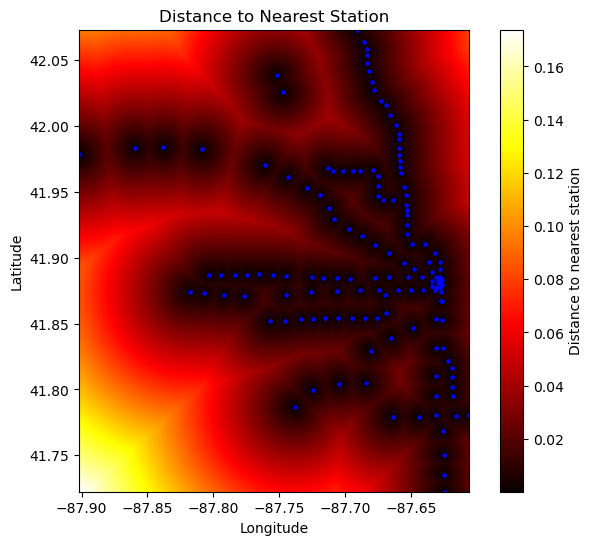

In [2]:

data = np.loadtxt('data/points/CTA_L_X_Y.txt', delimiter=",",skiprows=1)

lon = data[:,0]
lat = data[:,1]

points = np.column_stack((lon, lat))


grid_size = 200  

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

grid_lon = np.linspace(lon_min, lon_max, grid_size)
grid_lat = np.linspace(lat_min, lat_max, grid_size)

XX, YY = np.meshgrid(grid_lon, grid_lat)

grid_points = np.column_stack([XX.ravel(), YY.ravel()])

tree = cKDTree(points)

distances, _ = tree.query(grid_points, k=1)
distance_grid = distances.reshape((grid_size, grid_size))


plt.figure(figsize=(8,6))
plt.imshow(distance_grid, extent=[lon_min, lon_max, lat_min, lat_max],
           origin='lower', cmap='hot')
plt.colorbar(label='Distance to nearest station')

plt.scatter(lon, lat, c='blue', s=5)

plt.title("Distance to Nearest Station")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

[[0.01533064 0.0269599 ]
 [0.0097559  0.01929755]
 [0.03282275 0.03885638]
 [0.00873391 0.01469769]
 [0.01277402 0.01565037]
 [0.00690705 0.00967315]
 [0.00928272 0.01185994]
 [0.00954922 0.01194582]
 [0.00970998 0.01157729]
 [0.015149   0.01696767]
 [0.00750102 0.00929707]
 [0.0045609  0.00632235]
 [0.04705407 0.04868048]
 [0.00833231 0.0098723 ]
 [0.00963591 0.01102962]
 [0.00687907 0.00813547]
 [0.00528635 0.0065172 ]
 [0.00343356 0.00459051]
 [0.00761683 0.00871624]
 [0.01039984 0.01145812]
 [0.010941   0.01198258]
 [0.03418819 0.03522717]
 [0.00803929 0.00903751]
 [0.01289564 0.01384097]
 [0.00852569 0.0094531 ]
 [0.00597642 0.00690053]
 [0.01100549 0.01192391]
 [0.00516054 0.00599723]
 [0.03281994 0.03364349]
 [0.00729434 0.00809695]
 [0.00668326 0.00744816]
 [0.00672312 0.0074781 ]
 [0.03419781 0.03495215]
 [0.01685431 0.01758642]
 [0.00469163 0.00541737]
 [0.00804168 0.00876025]
 [0.00339531 0.00410017]
 [0.00984806 0.01054168]
 [0.03288755 0.03357793]
 [0.00985922 0.01054739]


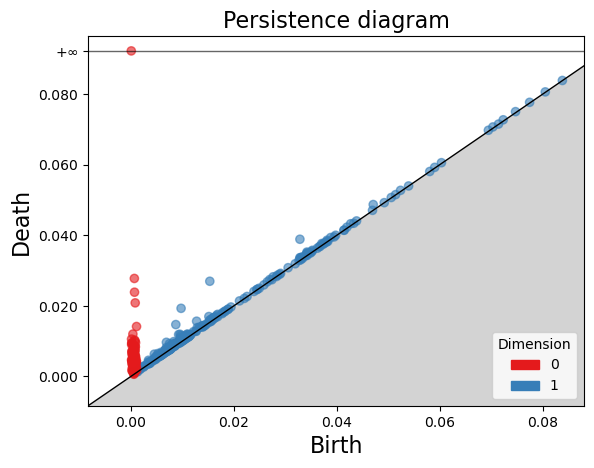

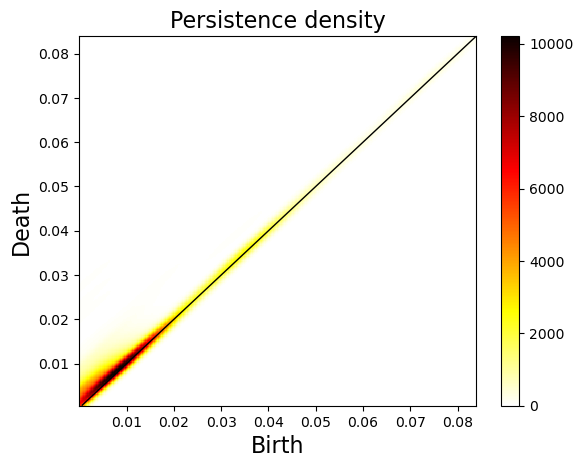

In [ ]:
flat = distance_grid.flatten()
dims = list(distance_grid.shape)

cc = gd.CubicalComplex(dimensions=dims, top_dimensional_cells=flat)

cc.compute_persistence()
barcodes= cc.persistence()
gd.plot_persistence_diagram(barcodes)
gd.plot_persistence_density(barcodes)

Ista1 = cc.persistence_intervals_in_dimension(1)
lifetimes1 = Ista1[:,1] - Ista1[:,0]
order = np.argsort(lifetimes1)[::-1]
Ista_sorted1 = Ista1[order]
print(Ista_sorted1)


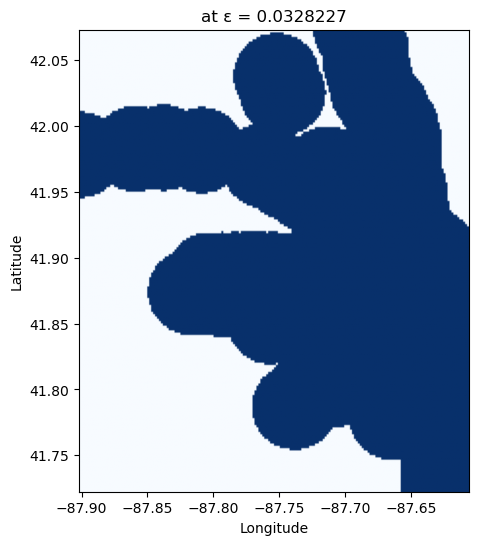

In [5]:
epsilon = 0.0328227

mask = distance_grid <= epsilon

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(mask,
           extent=[grid_lon.min(), grid_lon.max(),
                   grid_lat.min(), grid_lat.max()],
           origin='lower',
           cmap='Blues')

plt.title(f"at ε = {epsilon}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()